In [1]:
#imports

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from scipy.special import sph_harm

from schnell.mapping import MapCalculator
from schnell.detector import LISADetector

In [278]:
#constanten enzo

import numpy as np

C_LIGHT = 299_792_458.0
L_ARM   = 2.5e9
F_STAR  = C_LIGHT / (2*np.pi*L_ARM)

def absW2(f, tdi="1.5"):
    """
    Paper 1 Eq. (4.14):
      |W|^2 = 1 (TDI 1.0)
      |W|^2 = 4 sin^2(f/f*) (TDI 1.5)
    """
    f = np.asarray(f, float)
    if tdi == "1.0":
        return np.ones_like(f)
    if tdi == "1.5":
        return 4.0 * np.sin(f / F_STAR)**2
    raise ValueError("tdi must be '1.0' or '1.5'")

def scale_RN(f, tdi="1.5"):
    """S(f) = 4 (f/f*)^2 |W(f)|^2 appearing in Eq. (4.12)."""
    f = np.asarray(f, float)
    return 4.0 * (f / F_STAR)**2 * absW2(f, tdi=tdi)

MPC_M     = 3.0856775814913673e22
H0_OVER_h = (100.0 * 1000.0) / MPC_M  

P_OMS_PM = 15.0  
A_ACC_FM = 3.0  

In [1]:
import numpy as np
import healpy as hp

def healpix_sky(nside, nest=False):
    """Return khat (npix,3), theta, phi for HEALPix grid."""
    npix = hp.nside2npix(nside)
    ipix = np.arange(npix)
    theta, phi = hp.pix2ang(nside, ipix, nest=nest)
    khat = np.array(hp.ang2vec(theta, phi))  # (npix,3)
    return khat, theta, phi

def map2alm_complex_std(map_complex, lmax, iter=0):
    """
    Standard HEALPy convention:
      a_lm = ∫ map * Y_lm^* dΩ
    Works for complex map via real+imag split.
    """
    alm_re = hp.map2alm(np.real(map_complex), lmax=lmax, iter=iter)
    alm_im = hp.map2alm(np.imag(map_complex), lmax=lmax, iter=iter)
    return alm_re + 1j * alm_im

def map2alm_complex_Y(map_complex, lmax, iter=0):
    """
    (matches scipy sph_harm without conjugation in the dot-product):
      c_lm = ∫ map * Y_lm dΩ

    For m>=0:
      c_lm = conj( ∫ conj(map) * Y_lm^* dΩ ) = conj( map2alm(conj(map)) )

    Returns HEALPy-packed alm for m>=0 with this convention.
    """
    return np.conj(map2alm_complex_std(np.conj(map_complex), lmax=lmax, iter=iter))

def alm_get(alm, lmax, ell, m):
    """Fetch packed alm coefficient for ell, m (m>=0 only)."""
    return alm[hp.Alm.getidx(lmax, ell, m)]

def coeff_full_m_from_maps(alms_posY, alms_std, lmax, ell, m):
    """
    Return coefficient c_{ell m} = ∫ map * Y_{ell m} dΩ for any m in [-ell..ell].

    Inputs:
      alms_posY: packed alm (m>=0) for ∫ map Y_lm dΩ
      alms_std : packed alm (m>=0) for ∫ map Y_lm^* dΩ

    For m>=0: use alms_posY.
    For m<0 : use Y_{l,-m} = (-1)^m conj(Y_{l,m}) => c_{l,-m} = (-1)^m * a_std(l,m)
    """
    if m >= 0:
        return alm_get(alms_posY, lmax, ell, m)
    mp = -m
    return ((-1)**mp) * alm_get(alms_std, lmax, ell, mp)

In [2]:
#funties vanuit appendix B; N_TT tilde en N_AE tilde

def S_oms(f):
    f = np.asarray(f, dtype=float)
    return (P_OMS_PM * 1e-12)**2 * (1.0 + (2.0e-3 / f)**4)

def S_acc(f):
    f = np.asarray(f, dtype=float)
    return (A_ACC_FM * 1e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

def N_tilde_AE(f):
    f = np.asarray(f, dtype=float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = 0.5 * (2.0 + cosx) * (S_oms(f) / (L_ARM**2))
    term_acc = 2.0 * (1.0 + cosx + cosx**2) * (S_acc(f) / (L_ARM**2)) * (1.0 / (2.0*np.pi*f))**4
    return term_oms + term_acc

def N_tilde_T(f):
    f = np.asarray(f, dtype=float)
    f = np.maximum(f, 1e-6)
    x = f / F_STAR
    s2 = np.sin(x/2.0)**2        # stable for small x
    one_minus_cos = 2.0 * s2

    term_oms = one_minus_cos * (S_oms(f) / (L_ARM**2))
    term_acc = 2.0 * (one_minus_cos**2) * (S_acc(f) / (L_ARM**2)) * (1.0 / (2.0*np.pi*f))**4
    return term_oms + term_acc


In [3]:
C_AET = np.array([
    [-1/np.sqrt(2),  0.0,          1/np.sqrt(2)],   # A
    [ 1/np.sqrt(6), -2/np.sqrt(6), 1/np.sqrt(6)],   # E
    [ 1/np.sqrt(3),  1/np.sqrt(3), 1/np.sqrt(3)],   # T  Dit is Eq. 4.25, de andere verglijkingen werkte niet. Dus we doen het via DeltaF
    ], dtype=float)

OIDX = {"A": 0, "E": 1, "T": 2}


def Rlm_OOp_from_rlmij(mat_ij, O, Op):
    cO  = C_AET[OIDX[O]]
    cOp = C_AET[OIDX[Op]]
    return np.sum(cO[:, None] * cOp[None, :] * mat_ij) # dit is eq. 4.27 in de paper
    
def Rell_OOp_from_rlmij_fullm(rlm_ij_by_m, ell, O, Op):
    """
    RMS over m written as:
        sqrt( |z_0|^2 + 2 * sum_{m=1..ell} |z_m|^2 )
    assuming |z_{-m}|^2 = |z_m|^2.
    """
    # m = 0 contribution
    z0 = Rlm_OOp_from_rlmij(rlm_ij_by_m[0], O, Op)
    s = np.abs(z0)**2

    # m > 0 pairs
    for m in range(1, ell + 1):
        zm = Rlm_OOp_from_rlmij(rlm_ij_by_m[m], O, Op)
        s += 2 * np.abs(zm)**2

    return np.sqrt(s)

In [4]:
def Rell_OOp_analytical(rlm_ij_by_m, ell, channel):

    # Sort the pair to handle symmetry (e.g., 'EA' -> 'AE')
    pair = channel
    
    val_sq = 0.0
    
    # ==========================================
    # ODD MULTIPOLES (Equation 4.29)
    # ==========================================
    offset = ell
    if ell % 2 != 0:
        if pair in ["AA", "EE", "TT"]:
            return 0.0
        
        for m in range(-ell, ell + 1):
            # For odd l, we only need R_12
            mm = np.abs(m)
            R12 = rlm_ij_by_m[mm][0, 1]
            
            if pair in ["AE", "EA"]:
                coeff = (1.0 + 2.0 * (np.cos(2.0 * m * np.pi / 3.0)))**2
                val_sq += (1.0 / 3.0) * coeff * np.abs(R12)**2

            
            elif pair in ["AT", "ET", "TA", "TE"]:
                coeff = (np.sin(m * np.pi / 3.0))**2
                val_sq += 2.0 * coeff * np.abs(R12)**2

    # ==========================================
    # EVEN MULTIPOLES (Equation 4.30)
    # ==========================================
    else:
        for m in range(-ell, ell + 1):
            # For even l, we need both R_11 and R_12
            mm = np.abs(m)
            R11 = rlm_ij_by_m[mm][0, 0]
            R12 = rlm_ij_by_m[mm][0, 1]
            
            if pair in ["AA", "EE"]:
                phase_term = (1.0 + np.exp(-4.0/3.0 * 1j * m * np.pi))
                term = phase_term * R11 - 2.0 * R12
                val_sq += (1.0 / 4.0) * np.abs(term)**2
                
            elif pair == "TT":
                coeff = (1.0 + 2.0 * (np.cos(2.0 * m * np.pi / 3.0)))**2
                term = R11 + 2.0 * R12
                val_sq += (1.0 / 9.0) * coeff * np.abs(term)**2
                
            elif pair in ["AE", "EA"]:
                coeff = (np.sin(m * np.pi / 3.0))**2
                phase_term = 1.0 + np.exp(2.0/3.0 * 1j * m * np.pi)
                term = phase_term * R11 - 2.0 * R12
                val_sq += (1.0 / 3.0) * coeff * np.abs(term)**2
                
            elif pair in ["AT", "ET", "TA", "TE"]:
                coeff = (np.sin(m * np.pi / 3.0))**2
                phase_term = 1.0 + np.exp(2.0/3.0 * 1j * m * np.pi)
                term = phase_term * R11 + R12
                val_sq += (2.0 / 3.0) * coeff * np.abs(term)**2

    # Eq 4.28 specifies taking the square root of the sum
    return np.sqrt(val_sq)

In [326]:
def precompute_Ylm_star(nside, lmax):
    """
    Precompute Y*_{lm}(theta_p, phi_p) for all pixels p and all (l,m) with l<=lmax.
    Returns:
      Ystar: complex array shape (ncoeff, npix) where ncoeff = sum_{l=0}^lmax (2l+1)
      ell_of_k, m_of_k: int arrays length ncoeff
      dOmega: float
    """
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta, phi = hp.pix2ang(nside, pix)

    ncoeff = (lmax + 1)**2
    Ystar = np.empty((ncoeff, npix), dtype=np.complex128)
    ell_of_k = np.empty(ncoeff, dtype=np.int32)
    m_of_k   = np.empty(ncoeff, dtype=np.int32)

    k = 0
    for ell in range(lmax + 1):
        for m in range(-ell, ell + 1):
            # sph_harm gives Y_{lm}(phi,theta)
            Y = sph_harm(m, ell, phi, theta)
            Ystar[k, :] = np.conjugate(Y)
            ell_of_k[k] = ell
            m_of_k[k]   = m
            k += 1

    dOmega = 4.0 * np.pi / npix
    return Ystar, ell_of_k, m_of_k, dOmega

def map2alm_complex_fast(hp_map_complex, Ystar, ell_of_k, m_of_k, lmax, dOmega, mask=None):
    """
    Fast complex alm using precomputed Ystar:
      a_k = dOmega * sum_p f_p * Y*_k(p)
    Returns alm_fullm with shape (lmax+1, 2*lmax+1).
    """
    f = np.asarray(hp_map_complex, dtype=np.complex128)
    if mask is not None:
        f = f * np.asarray(mask, dtype=float)

    # vector of coefficients (ncoeff,)
    a = dOmega * (Ystar @ f)

    alm = np.zeros((lmax + 1, 2*lmax + 1), dtype=np.complex128)
    for ak, ell, m in zip(a, ell_of_k, m_of_k):
        alm[ell, m + lmax] = ak
    return alm

In [327]:
def compute_Rlm_ij(f_grid, lmax, nside, t0=0.0, lmax_full=None):
    """
    Optimized version:
      rlm_all[i_f][i][j] is alm_fullm shape (lmax+1, 2*lmax+1)
    """
    f_grid = np.asarray(f_grid, dtype=float)
    lmax = int(lmax)

    if lmax_full is None:
        # For Fig.9 with lmax=10, this is the right speed/accuracy tradeoff
        lmax_full = lmax
    lmax_full = lmax

    dets = [LISADetector(detector_id=i) for i in range(3)]
    mc = MapCalculator(dets)

    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    # Precompute basis once
    Ystar, ell_of_k, m_of_k, dOmega = precompute_Ylm_star(nside, lmax_full)

    def antenna_alm_fullm(i, j, f):
        ant = mc.get_antenna(i, j, float(t0), float(f), theta, phi,
                     pol=False, inc_baseline=True)
        ant = np.asarray(ant, dtype=np.complex128)

        # --- ADD THIS: apply the Paper-1 TDI factor (choose the one used for Fig. 9) ---
        if ant.shape != (npix,):
            raise RuntimeError(f"get_antenna returned {ant.shape}, expected {(npix,)}")

        alm_full = map2alm_complex_fast(
            ant, Ystar, ell_of_k, m_of_k, lmax_full, dOmega
        )
        pw = hp.sphtfunc.pixwin(nside, lmax=lmax_full)  # length lmax_full+1
        for ell in range(lmax_full + 1):
            if pw[ell] != 0:
                alm_full[ell, :] /= pw[ell]

        # Truncate if lmax_full > lmax (most times they are equal)
        if lmax_full == lmax:
            return alm_full
        else:
            alm_out = np.zeros((lmax + 1, 2*lmax + 1), dtype=np.complex128)
            for ell in range(lmax + 1):
                for m in range(-ell, ell + 1):
                    alm_out[ell, m + lmax] = alm_full[ell, m + lmax_full]
            return alm_out

    rlm_all = []
    for f in f_grid:
        M = [[None]*3 for _ in range(3)]
        for i in range(3):
            for j in range(3):
                M[i][j] = antenna_alm_fullm(i, j, f)
        rlm_all.append(M)

    return rlm_all

In [328]:
# functies 4.42 en 4.43 uit de paper
# autos (AA, EE, TT) en crosses (AE+EA, AT+TA, ET+TE).

def omega_channel_channel_tilde(f, Rtilde_ell, Ntilde1, Ntilde2):
    pref = (4.0 * np.pi**2 * np.sqrt(4.0 * np.pi)) / (3.0 * (H0_OVER_h**2))
    return pref * (f**3) *(np.sqrt(Ntilde1 * Ntilde2) / (Rtilde_ell))

    
def omega_combined_from_channels(omega_auto, omega_cross):
    inv2 = np.zeros_like(omega_auto[0], dtype=float)

    # autos: AA, EE, TT appear once in sum_{O,O'}
    for om in omega_auto:
        inv2 += 1.0 / (om * om)

    # crosses: AE and EA (etc.)
    for om in omega_cross:
        inv2 += 1.0 / (om * om)

    return 1.0 / np.sqrt(inv2)

In [329]:
def recreate_figure9_clean(f_grid, lmax, nside, t0=0.0):

    f_grid = np.asarray(f_grid, dtype=float)

    # --- response alms (assumed to represent the tilde-response spherical harmonics you want)
    rlm_all = compute_Rlm_ij(f_grid, lmax=lmax, nside=nside, t0=t0)

    # --- tilde noises
    N_A = N_tilde_AE(f_grid)
    N_E = N_A.copy()
    N_T = N_tilde_T(f_grid)
    N_map = {"A": N_A, "E": N_E, "T": N_T}


    # plotting convention
    Y00 = 1.0 / np.sqrt(8.0 * np.pi)

    pairs = [
        ("A", "A", "AA"),
        ("E", "E", "EE"),
        ("T", "T", "TT"),
        ("A", "E", "AE"),
        ("A", "T", "AT"),
        ("E", "T", "ET"),
        ("E", "A", "EA"),
        ("T", "A", "TA"),
        ("T", "E", "TE"),
    ]

    omega_ell = {}

    for ell in range(lmax + 1):

        # store tilde R^ell_{OO'}(f)
        Rell = {key: np.zeros_like(f_grid, dtype=float) for _, _, key in pairs}
        half_way = len(f_grid) / 2
        for i_f in range(len(f_grid)):

            # build full m dictionary of 3x3 matrices of tilde R^{ell m}_{ij}(f)
            rlm_ij_by_m = {}
            for m in range(-ell, ell + 1):
                mat = np.zeros((3, 3), dtype=np.complex128)
                for i in range(3):
                    for j in range(3):
                        # rlm_all[i_f][i][j] has shape (lmax+1, 2*lmax+1)
                        mat[i, j] = rlm_all[i_f][i][j][ell, m + lmax]
                rlm_ij_by_m[m] = mat

            # RMS over m -> tilde R^ell_{OO'}(f)
            if ell in [ ]: 
                for key in ["AA","EE","TT","AE","AT","ET","EA","TA","TE"]:
                    channel = key
                    val = Rell_OOp_analytical(rlm_ij_by_m, ell, channel)
                    Rell[key][i_f] = val
            else:       
                for O, Op, key in pairs:
                    Rell[key][i_f] = float(Rell_OOp_from_rlmij_fullm(rlm_ij_by_m, ell, O, Op))
                    
        # --- compute Omega per pair (tilde formula)
        def omega_pair(R, N1, N2):
            om = np.full_like(f_grid, np.inf, dtype=float)
            mask = (R >= 0) & np.isfinite(N1) & np.isfinite(N2)
            if np.any(mask):
                om[mask] = omega_channel_channel_tilde(f_grid[mask], R[mask], N1[mask], N2[mask])
            return om

        omega_auto = []
        for O in ["A", "E", "T"]:
            key = O + O
            omega_auto.append(omega_pair(Rell[key], N_map[O], N_map[O]))

        omega_cross = []
        for (O1, O2, key) in [("A", "E", "AE"), ("A", "T", "AT"), ("E", "T", "ET"),("E", "A", "EA"), ("T", "A", "TA"), ("T", "E", "TE")]:
            omega_cross.append(omega_pair(Rell[key], N_map[O1], N_map[O2]))

        omega_comb = omega_combined_from_channels(omega_auto, omega_cross)

        omega_ell[ell] = omega_comb * Y00

    return omega_ell

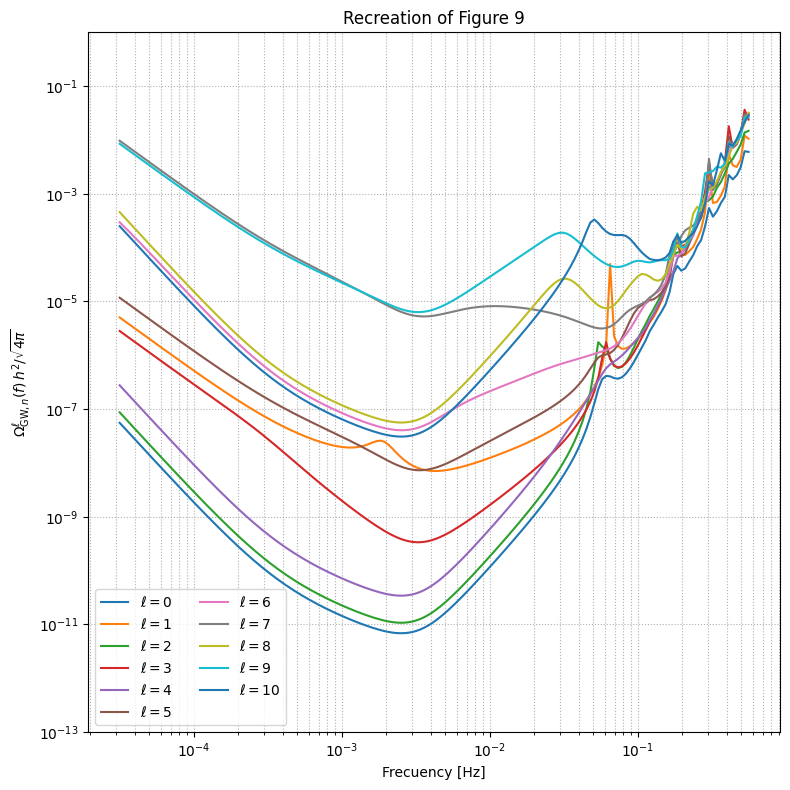

In [331]:
#plotter broertje

f = np.logspace(-4.5, -0.25, 160)
curves = recreate_figure9_clean(f, lmax=10, nside=32)

plt.figure(figsize=(8, 8))
for ell in range(0, 11):
    plt.loglog(f, curves[ell], label=fr"$\ell={ell}$")

plt.xlabel("Frecuency [Hz]")
plt.ylim([1e-13, 1e0])
plt.ylabel(r"$\Omega^{\ell}_{{\rm GW},n}(f)\,h^2 / \sqrt{4\pi}$")
plt.title("Recreation of Figure 9")
plt.grid(True, which="both", ls=":")
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

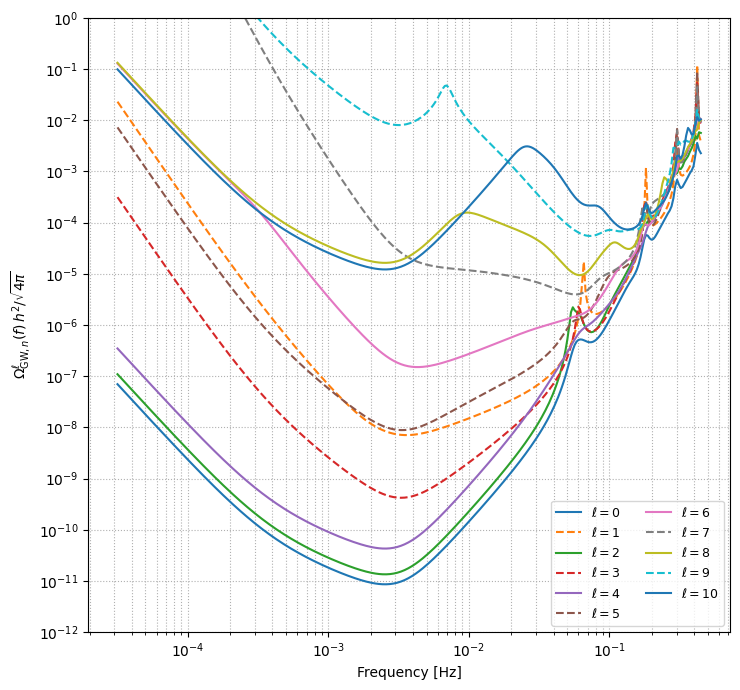

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from matplotlib.ticker import LogLocator, LogFormatterMathtext


# ============================================================
# Constants (paper)
# ============================================================
C_LIGHT = 299_792_458.0
L_ARM   = 2.5e9
F_STAR  = C_LIGHT / (2.0*np.pi*L_ARM)

MPC_M     = 3.0856775814913673e22
H0_OVER_h = (100.0 * 1000.0) / MPC_M

P_OMS_PM = 15.0
A_ACC_FM = 3.0

# Paper plotting rescaling
Y00 = 1.0 / np.sqrt(8.0*np.pi)

# ============================================================
# Appendix B: Noise functions
# ============================================================
def S_oms(f):
    f = np.asarray(f, float)
    return (P_OMS_PM * 1e-12)**2 * (1.0 + (2.0e-3 / f)**4)

def S_acc(f):
    f = np.asarray(f, float)
    return (A_ACC_FM * 1e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

def N_tilde_AE(f):
    f = np.asarray(f, float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = 0.5 * (2.0 + cosx) * (S_oms(f) / L_ARM**2)
    term_acc = 2.0 * (1.0 + cosx + cosx**2) * (S_acc(f) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc

def N_tilde_T(f):
    f = np.asarray(f, float)
    x = f / F_STAR
    one_minus_cos = 1.0 - np.cos(x)
    term_oms = one_minus_cos * (S_oms(f) / L_ARM**2)
    term_acc = 2.0 * (one_minus_cos**2) * (S_acc(f) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc

# ============================================================
# Appendix A helpers (same math as before)
# ============================================================
def sinc(x):
    x = np.asarray(x)
    out = np.ones_like(x, dtype=np.complex128)
    small = np.abs(x) < 1e-12
    xs = x[~small]
    out[~small] = np.sin(xs) / xs
    return out

def M_transfer(u, mu):
    arg = 0.5 * u * (1.0 + mu)
    return np.exp(1j * arg) * sinc(arg)

def T_transfer(u, mu):
    return np.exp(-1j*u) * M_transfer(u, -mu) + np.exp(-1j*u*mu) * M_transfer(u, mu)

# ============================================================
# Polarization tensors and projections on a HEALPix grid
# ============================================================
def healpix_grid(nside):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix), nest=False)
    sin_t = np.sin(theta)
    khat = np.stack([sin_t*np.cos(phi), sin_t*np.sin(phi), np.cos(theta)], axis=1)
    return khat, theta, phi

def polarization_tensors_from_k(khat, theta, phi):
    e_theta = np.stack([np.cos(theta)*np.cos(phi),
                        np.cos(theta)*np.sin(phi),
                        -np.sin(theta)], axis=1)
    e_phi = np.stack([-np.sin(phi),
                      np.cos(phi),
                      np.zeros_like(phi)], axis=1)
    e_plus  = e_theta[:, :, None]*e_theta[:, None, :] - e_phi[:, :, None]*e_phi[:, None, :]
    e_cross = e_theta[:, :, None]*e_phi[:, None, :]   + e_phi[:, :, None]*e_theta[:, None, :]
    return e_plus, e_cross

def g_pol_from_arm(lhat, e_tensor):
    return 0.5 * np.einsum("i,j,nij->n", lhat, lhat, e_tensor)

# ============================================================
# A,E,T channel mixing (paper Eq. 4.25)
# ============================================================
C_AET = np.array([
    [-1/np.sqrt(2),  0.0,           1/np.sqrt(2)],  # A
    [ 1/np.sqrt(6), -2/np.sqrt(6),  1/np.sqrt(6)],  # E
    [ 1/np.sqrt(3),  1/np.sqrt(3),  1/np.sqrt(3)],  # T
], dtype=float)
O_list = ["A", "E", "T"]
O_idx  = {O: i for i, O in enumerate(O_list)}

# ============================================================
# Sensitivity equations (paper Eqs. 4.42-4.43)
# ============================================================
def omega_channel_channel(f, Rtilde, Ntilde_O, Ntilde_Op):
    pref = (4.0*np.pi**2 * np.sqrt(4.0*np.pi)) / (3.0 * (H0_OVER_h**2))
    return pref * (f**3) * (np.sqrt(Ntilde_O * Ntilde_Op) / Rtilde)

def optimal_omega_from_ordered_pairs(omega_pairs_9):
    inv2 = np.zeros_like(omega_pairs_9[0], dtype=float)
    for om in omega_pairs_9:
        inv2 += 1.0 / (om*om)
    return 1.0 / np.sqrt(inv2)

# ============================================================
# Key point for "real basis" + iter=1 with complex sky maps
# ============================================================
# healpy.map2alm(...) assumes a *real* map (standard use case).
# Our per-frequency sky maps are complex because of exp(-2π i f k·Δx).
#
# To use healpy's SHT machinery (and thus iter=1) while keeping the *full*
# complex harmonic content, we compute:
#   a_{lm}^*basis  = ∫ f(Ω) Y_{lm}^*(Ω) dΩ  via map2alm(Re f) + i map2alm(Im f)
# and also
#   b_{lm}         = ∫ f(Ω) Y_{lm}(Ω)  dΩ  via map2alm(Re f) - i map2alm(Im f) but with
# the correct operation: b_{lm} = (∫ f*(Ω) Y_{lm}^*(Ω) dΩ)^*.
#
# For any complex f:
#   c_{lm} := ∫ f*(Ω) Y_{lm}^*(Ω) dΩ
# then
#   b_{lm} = c_{lm}^*.
#
# So we compute:
#   alm_f  = map2alm(Re f) + i map2alm(Im f)         (m>=0 stored)
#   alm_fc = map2alm(Re f) - i map2alm(Im f)         equals map2alm(conj(f)) (linearity)
# and use:
#   power_l = |a_{l0}|^2 + sum_{m=1..l} ( |a_{lm}|^2 + |c_{lm}|^2 )
# where c_{lm} are the coefficients from alm_fc (since alm_fc = c_{lm} for m>=0).
#
# This quantity equals sum_{m=-l..l} |Z_{lm}|^2 for the complex-harmonic basis,
# i.e. the rotation-invariant response used in the paper.
#
# ============================================================

def precompute_alm_indices(lmax):
    idx_by_ell = {}
    idx_mpos_by_ell = {}
    for ell in range(lmax + 1):
        idxs = [hp.Alm.getidx(lmax, ell, m) for m in range(0, ell + 1)]
        idx_by_ell[ell] = np.array(idxs, dtype=np.int64)
        if ell >= 1:
            idxs_mpos = [hp.Alm.getidx(lmax, ell, m) for m in range(1, ell + 1)]
            idx_mpos_by_ell[ell] = np.array(idxs_mpos, dtype=np.int64)
        else:
            idx_mpos_by_ell[ell] = np.array([], dtype=np.int64)
    return idx_by_ell, idx_mpos_by_ell

def reproduce_figure9_healpy_real_basis_iter1(f_grid, lmax=10, nside=32, iter_sht=1):
    """
    Uses healpy's spherical harmonic transform with iter=iter_sht (e.g. 1),
    while correctly accounting for complex sky maps by computing both:
      a_lm = ∫ f Y_lm^* dΩ
      c_lm = ∫ f* Y_lm^* dΩ
    and forming:
      sum_{m=-l..l} |Z_lm|^2  ==  |a_l0|^2 + Σ_{m=1..l} (|a_lm|^2 + |c_lm|^2)

    This is equivalent to working in a real spherical-harmonic basis (cos/sin modes),
    and it allows use of iter=1 without losing the negative-m information.
    """
    f_grid = np.asarray(f_grid, float)
    if lmax > 3*nside - 1:
        raise ValueError(f"HEALPix sampling constraint: need lmax <= 3*nside-1, got lmax={lmax}, nside={nside}")

    # --- Geometry (same as before)
    L = L_ARM
    r1 = np.array([0.0, 0.0, 0.0])
    r2 = np.array([L,   0.0, 0.0])
    r3 = np.array([0.5*L, 0.5*np.sqrt(3.0)*L, 0.0])
    pos = [r1, r2, r3]

    def unit(v):
        return v / np.linalg.norm(v)

    l12 = unit(r2-r1); l13 = unit(r3-r1)
    l21 = unit(r1-r2); l23 = unit(r3-r2)
    l31 = unit(r1-r3); l32 = unit(r2-r3)

    arms_by_sc = {0: (l12, l13), 1: (l23, l21), 2: (l31, l32)}

    pos_sec = [p / C_LIGHT for p in pos]
    delta_sec = np.zeros((3, 3, 3))
    for i in range(3):
        for j in range(3):
            delta_sec[i, j] = pos_sec[i] - pos_sec[j]

    # --- HEALPix sky (ring)
    khat, theta, phi = healpix_grid(nside)
    npix = khat.shape[0]

    # Polarization tensors on sky
    e_plus, e_cross = polarization_tensors_from_k(khat, theta, phi)

    # --- Precompute arm-dependent sky projections (geometry-only)
    mu_a  = np.empty((3, npix), dtype=np.float64)
    mu_b  = np.empty((3, npix), dtype=np.float64)
    gp_a  = np.empty((3, npix), dtype=np.float64)
    gx_a  = np.empty((3, npix), dtype=np.float64)
    gp_b  = np.empty((3, npix), dtype=np.float64)
    gx_b  = np.empty((3, npix), dtype=np.float64)

    for i in range(3):
        la, lb = arms_by_sc[i]
        mu_a[i] = khat @ la
        mu_b[i] = khat @ lb
        gp_a[i] = g_pol_from_arm(la, e_plus).real
        gx_a[i] = g_pol_from_arm(la, e_cross).real
        gp_b[i] = g_pol_from_arm(lb, e_plus).real
        gx_b[i] = g_pol_from_arm(lb, e_cross).real

    # --- Precompute k·Δx_ij on pixels
    kdot_delta = np.zeros((3, 3, npix), dtype=np.float64)
    for i in range(3):
        for j in range(3):
            kdot_delta[i, j] = khat @ delta_sec[i, j]
    kdot_flat = kdot_delta.reshape(9, npix)

    # --- Precompute mixing from ij-flat(9) to ordered channel pairs(9)
    pairs = [(O, Op) for O in O_list for Op in O_list]  # 9 ordered
    Mix = np.empty((9, 9), dtype=np.float64)
    for pidx, (O, Op) in enumerate(pairs):
        cO  = C_AET[O_idx[O]]
        cOp = C_AET[O_idx[Op]]
        Mix[pidx, :] = (cO[:, None] * cOp[None, :]).reshape(9)

    # --- Noise arrays
    N_A = N_tilde_AE(f_grid)
    N_E = N_A.copy()
    N_T = N_tilde_T(f_grid)
    N_map = {"A": N_A, "E": N_E, "T": N_T}

    # --- ALM index helpers
    idx_by_ell, idx_mpos_by_ell = precompute_alm_indices(lmax)

    # Output
    omega_by_ell = {ell: np.zeros_like(f_grid) for ell in range(lmax + 1)}

    # Work arrays
    Rplus  = np.empty((3, npix), dtype=np.complex128)
    Rcross = np.empty((3, npix), dtype=np.complex128)

    # Normalization prefactor for Eq. (4.15): 1/(8π)
    pref_Rlm = 1.0 / (8.0 * np.pi)

    # Main frequency loop
    for fi, f in enumerate(f_grid):
        u = f / F_STAR

        # Transfer functions for each arm (vectorized)
        Ta_a = T_transfer(u, mu_a)  # (3,npix) complex
        Ta_b = T_transfer(u, mu_b)  # (3,npix) complex

        # R_i^+, R_i^x
        Rplus[:]  = gp_a * Ta_a - gp_b * Ta_b
        Rcross[:] = gx_a * Ta_a - gx_b * Ta_b

        # Σ_A R_i^A R_j^{A*}
        pol_sum = (Rplus[:, None, :] * np.conj(Rplus[None, :, :]) +
                   Rcross[:, None, :] * np.conj(Rcross[None, :, :]))  # (3,3,npix)

        # phase for all ij at once
        phase_flat = np.exp(-2j * np.pi * f * kdot_flat)  # (9,npix)

        # Eq. (4.15) sky "maps" for each ij (flattened): f_ij(Ω) = (1/8π) pol_sum * phase
        maps_ij_flat = pref_Rlm * pol_sum.reshape(9, npix) * phase_flat  # (9,npix) complex

        # Mix ij maps into 9 ordered channel-pair maps (still on sky pixels)
        # maps_pair[pair, pix] = Σ_ij Mix[pair,ij] * maps_ij[ij,pix]
        maps_pair = Mix @ maps_ij_flat  # (9,npix) complex

        # For each channel-pair map, compute two ALM sets:
        #  alm_a : a_lm = ∫ f Y_lm^* dΩ (m>=0 stored)
        #  alm_c : c_lm = ∫ f* Y_lm^* dΩ (m>=0 stored), which we get via map2alm(conj(f))
        #
        # Since healpy expects real map input, we do:
        #  map2alm(Re f) and map2alm(Im f) separately, then combine.
        #
        # For conj(f): Re same, Im negated.
        alms_a = []
        alms_c = []
        for pidx in range(9):
            mp = maps_pair[pidx]
            mp_re = mp.real.astype(np.float64, copy=False)
            mp_im = mp.imag.astype(np.float64, copy=False)

            # a_lm = A + i B
            A = hp.map2alm(mp_re, lmax=lmax, iter=iter_sht, pol=False)
            B = hp.map2alm(mp_im, lmax=lmax, iter=iter_sht, pol=False)
            alm_a = A + 1j * B

            # c_lm = map2alm(conj(f)) = map2alm(Re f - i Im f) = A - i B
            alm_c = A - 1j * B

            alms_a.append(alm_a)
            alms_c.append(alm_c)

        # Now compute Rtilde^ell for each pair using full m power:
        # power_ell = |a_l0|^2 + Σ_{m=1..ell} ( |a_lm|^2 + |c_lm|^2 )
        for ell in range(lmax + 1):
            idx0 = hp.Alm.getidx(lmax, ell, 0)
            idxm = idx_mpos_by_ell[ell]

            Rtilde_pairs = np.empty(9, dtype=np.float64)
            for pidx in range(9):
                aa = alms_a[pidx]
                cc = alms_c[pidx]

                power = np.abs(aa[idx0])**2
                if idxm.size > 0:
                    power += np.sum(np.abs(aa[idxm])**2) + np.sum(np.abs(cc[idxm])**2)

                Rtilde_pairs[pidx] = np.sqrt(power)
            Rtilde_pairs = np.maximum(Rtilde_pairs, 1e-45)

            # Build 9 Omegas for ordered pairs and optimally combine
            omega_pairs = []
            for pidx, (O, Op) in enumerate(pairs):
                omega_pairs.append(
                    omega_channel_channel(f, Rtilde_pairs[pidx], N_map[O][fi], N_map[Op][fi])
                )

            omega_by_ell[ell][fi] = optimal_omega_from_ordered_pairs(omega_pairs) * Y00

    return omega_by_ell

# ============================================================
# Example run + plot
# ============================================================
if __name__ == "__main__":
    f = np.logspace(-4.5, -0.35, 320)

    # More accuracy via iter=1 on the SHT side; true integral accuracy still improves with nside
    curves = reproduce_figure9_healpy_real_basis_iter1(
        f_grid=f,
        lmax=10,
        nside=960,      # increase for better angular accuracy
        iter_sht=0    # your request
    )

    plt.figure(figsize=(7.5, 7))
    for ell in range(0, 11):
        ls = "-" if (ell % 2 == 0) else "--"
        plt.loglog(f, curves[ell], linestyle=ls, label=rf"$\ell={ell}$")
    
    plt.xlabel("Frequency [Hz]")
    plt.ylabel(r"$\Omega^{\ell}_{{\rm GW},n}(f)\,h^2 / \sqrt{4\pi}$")
    plt.ylim(1e-12, 1e0)
    
    ax = plt.gca()
    
    # Show every power of 10 on the y-axis
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    
    plt.grid(True, which="both", linestyle=":")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()